In [ ]:
import marimo as mo

mo.md(
    """
    # Predictive Uncertainty and LOVE Variance

    `variance_method="exact"` computes the exact predictive variance for the
    requested test batch. `variance_method="love"` uses a prepared LOVE cache
    to approximate the same variance faster.

    This notebook shows both things explicitly: exact-vs-LOVE variance curves
    and repeated notebook wall-clock prediction timings on the same trained GP
    and the same `X_test` grid.
    """
)

# Predictive Uncertainty and LOVE Variance

`variance_method="exact"` computes the exact predictive variance for the
requested test batch. `variance_method="love"` uses a prepared LOVE cache
to approximate the same variance faster.

This notebook shows both things explicitly: exact-vs-LOVE variance curves
and repeated notebook wall-clock prediction timings on the same trained GP
and the same `X_test` grid.

In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

from mojogp import RBF, SingleOutputGP

warnings.simplefilter("ignore")
_rng = np.random.default_rng(11)
X_train = np.linspace(-4, 4, 90, dtype=np.float32).reshape(-1, 1)
X_test = np.linspace(-5.0, 5.0, 500, dtype=np.float32).reshape(-1, 1)
y_true = (np.sin(1.4 * X_test[:, 0]) + 0.25 * np.cos(2.8 * X_test[:, 0])).astype(
    np.float32
)
y_train = (
    np.sin(1.4 * X_train[:, 0])
    + 0.25 * np.cos(2.8 * X_train[:, 0])
    + 0.12 * _rng.standard_normal(len(X_train))
).astype(np.float32)

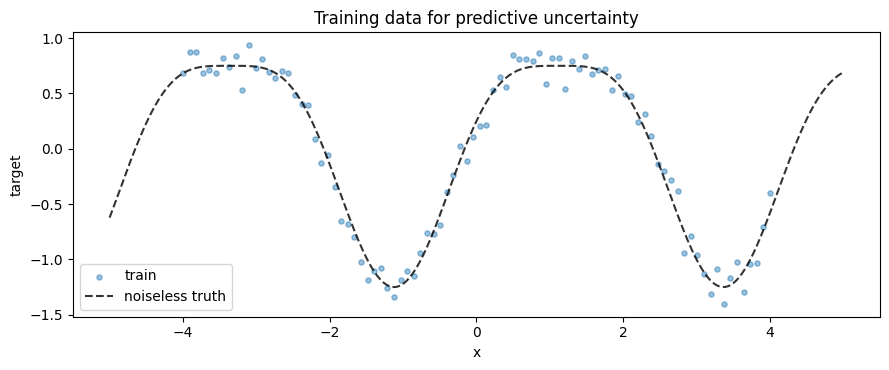

In [ ]:
_fig, _ax = plt.subplots(figsize=(9, 3.8))
_ax.scatter(X_train[:, 0], y_train, s=14, alpha=0.45, label="train")
_ax.plot(X_test[:, 0], y_true, "k--", alpha=0.8, label="noiseless truth")
_ax.set_title("Training data for predictive uncertainty")
_ax.set_xlabel("x")
_ax.set_ylabel("target")
_ax.legend()
_fig.tight_layout()
mo.mpl.interactive(_fig)

In [ ]:
import time

prediction_cache_rank = 32
gp = SingleOutputGP(RBF(lengthscale=0.9, outputscale=1.0))
train_result = gp.fit(
    X_train,
    y_train,
    max_iterations=20,
    learning_rate=0.035,
    method="materialized",
    prepare_prediction_cache=True,
    prediction_cache_rank=prediction_cache_rank,
    verbose=False,
    progress=True,
)

def timed_predict(variance_method, repeats=7):
    _kwargs = {}
    if variance_method == "love":
        _kwargs["max_root_decomposition_size"] = prediction_cache_rank
    _timings = []
    _prediction = None
    for _ in range(repeats):
        _start = time.perf_counter()
        _prediction = gp.predict(
            X_test,
            variance_method=variance_method,
            progress=True,
            **_kwargs,
        )
        _timings.append(time.perf_counter() - _start)
    return _prediction, _timings, dict(gp.backend_predict_info or {})

gp.predict(X_test, variance_method="exact", progress=True)
gp.predict(
    X_test,
    variance_method="love",
    max_root_decomposition_size=prediction_cache_rank,
    progress=True,
)
exact_prediction, exact_times, exact_info = timed_predict("exact")
love_prediction, love_times, love_info = timed_predict("love")

def summarize_times(times):
    _values = np.asarray(times, dtype=np.float64)
    return {
        "median_s": float(np.median(_values)),
        "min_s": float(np.min(_values)),
        "max_s": float(np.max(_values)),
    }

exact_timing = summarize_times(exact_times)
love_timing = summarize_times(love_times)
timing_speedup = exact_timing["median_s"] / max(love_timing["median_s"], 1e-12)

mean_max_abs_diff = float(np.max(np.abs(exact_prediction.mean - love_prediction.mean)))
variance_abs_diff = np.abs(exact_prediction.variance - love_prediction.variance)
variance_rmse = float(np.sqrt(np.mean(variance_abs_diff**2)))
variance_rel_rmse = float(
    variance_rmse / (np.mean(np.maximum(exact_prediction.variance, 1e-12)) + 1e-12)
)
variance_max_abs_diff = float(np.max(variance_abs_diff))
predictive_mean_rmse = float(np.sqrt(np.mean((exact_prediction.mean - y_true) ** 2)))

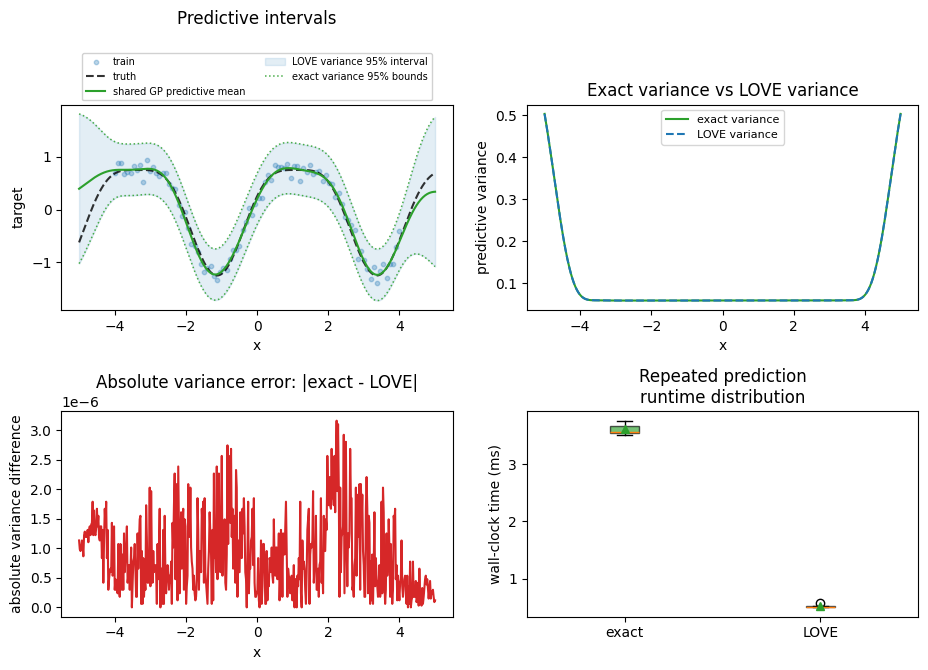

In [ ]:
_fig, _axes = plt.subplots(2, 2, figsize=(9.5, 6.8))
_interval_ax, _variance_ax, _error_ax, _timing_ax = _axes.ravel()

_interval_ax.scatter(X_train[:, 0], y_train, s=10, alpha=0.30, label="train")
_interval_ax.plot(X_test[:, 0], y_true, "k--", alpha=0.8, label="truth")
_shared_mean = exact_prediction.mean
_interval_ax.plot(X_test[:, 0], _shared_mean, color="tab:green", label="shared GP predictive mean")
_interval_ax.fill_between(
    X_test[:, 0],
    _shared_mean - 2 * love_prediction.std,
    _shared_mean + 2 * love_prediction.std,
    color="tab:blue",
    alpha=0.12,
    label="LOVE variance 95% interval",
)
_exact_lower = _shared_mean - 2 * exact_prediction.std
_exact_upper = _shared_mean + 2 * exact_prediction.std
_interval_ax.plot(
    X_test[:, 0],
    _exact_lower,
    color="tab:green",
    linestyle=":",
    linewidth=1.1,
    alpha=0.85,
    label="exact variance 95% bounds",
)
_interval_ax.plot(
    X_test[:, 0],
    _exact_upper,
    color="tab:green",
    linestyle=":",
    linewidth=1.1,
    alpha=0.85,
)
_interval_ax.set_title("Predictive intervals", pad=58)
_interval_ax.set_xlabel("x")
_interval_ax.set_ylabel("target")
_interval_ax.legend(
    fontsize=7,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    framealpha=0.9,
    borderaxespad=0.0,
)

_variance_ax.plot(X_test[:, 0], exact_prediction.variance, color="tab:green", label="exact variance")
_variance_ax.plot(
    X_test[:, 0],
    love_prediction.variance,
    color="tab:blue",
    linestyle="--",
    label="LOVE variance",
)
_variance_ax.set_title("Exact variance vs LOVE variance")
_variance_ax.set_xlabel("x")
_variance_ax.set_ylabel("predictive variance")
_variance_ax.legend(fontsize=8)

_error_ax.plot(X_test[:, 0], variance_abs_diff, color="tab:red")
_error_ax.set_title("Absolute variance error: |exact - LOVE|")
_error_ax.set_xlabel("x")
_error_ax.set_ylabel("absolute variance difference")

_timing_ms = [
    [1000.0 * _value for _value in exact_times],
    [1000.0 * _value for _value in love_times],
]
_box = _timing_ax.boxplot(
    _timing_ms,
    labels=["exact", "LOVE"],
    patch_artist=True,
    showmeans=True,
)
for _patch, _color in zip(_box["boxes"], ["tab:green", "tab:blue"]):
    _patch.set_facecolor(_color)
    _patch.set_alpha(0.65)
_timing_ax.set_title("Repeated prediction\nruntime distribution")
_timing_ax.set_ylabel("wall-clock time (ms)")
_fig.tight_layout()
mo.mpl.interactive(_fig)

In [ ]:
summary_rows = [
    {"Quantity": "Predictive mean RMSE vs noiseless function", "Value": f"{predictive_mean_rmse:.4f}"},
    {"Quantity": "Max mean difference between routes", "Value": f"{mean_max_abs_diff:.8f}"},
    {"Quantity": "Variance RMSE, LOVE vs exact", "Value": f"{variance_rmse:.6f}"},
    {"Quantity": "Variance relative RMSE, LOVE vs exact", "Value": f"{variance_rel_rmse:.4f}"},
    {"Quantity": "Max absolute variance difference", "Value": f"{variance_max_abs_diff:.6f}"},
    {"Quantity": "Exact median prediction time", "Value": f"{exact_timing['median_s'] * 1000.0:.2f} ms"},
    {"Quantity": "LOVE median prediction time", "Value": f"{love_timing['median_s'] * 1000.0:.2f} ms"},
    {"Quantity": "LOVE speedup vs exact", "Value": f"{timing_speedup:.2f}x"},
    {"Quantity": "Final NLL", "Value": f"{train_result.nll:.4f}"},
    {"Quantity": "Requested LOVE cache rank", "Value": f"{prediction_cache_rank}"},
    {"Quantity": "LOVE cache used", "Value": f"{love_info.get('prediction_cache_used', False)}"},
    {"Quantity": "LOVE cache has root", "Value": f"{love_info.get('prediction_cache_has_love_root', False)}"},
    {"Quantity": "LOVE variance route", "Value": f"{love_info.get('actual_variance_route', 'n/a')}"},
    {"Quantity": "Exact variance route", "Value": f"{exact_info.get('actual_variance_route', 'n/a')}"},
]

mo.vstack(
    [
        mo.ui.table(summary_rows, label="Exact variance vs LOVE variance and runtime"),
        mo.md(
            """
            Timings here are repeated warm notebook wall-clock timings.
            """
        ),
    ]
)

<marimo-table data-initial-value='[]' data-label='"<span class=\"markdown prose dark:prose-invert contents\"><span class=\"paragraph\">Exact variance vs LOVE variance and runtime</span></span>"' data-data='"[{\"Quantity\":\"Predictive mean RMSE vs noiseless function\",\"Value\":\"0.1869\"},{\"Quantity\":\"Max mean difference between routes\",\"Value\":\"0.00000000\"},{\"Quantity\":\"Variance RMSE, LOVE vs exact\",\"Value\":\"0.000001\"},{\"Quantity\":\"Variance relative RMSE, LOVE vs exact\",\"Value\":\"0.0000\"},{\"Quantity\":\"Max absolute variance difference\",\"Value\":\"0.000003\"},{\"Quantity\":\"Exact median prediction time\",\"Value\":\"3.57 ms\"},{\"Quantity\":\"LOVE median prediction time\",\"Value\":\"0.51 ms\"},{\"Quantity\":\"LOVE speedup vs exact\",\"Value\":\"6.98x\"},{\"Quantity\":\"Final NLL\",\"Value\":\"-0.1552\"},{\"Quantity\":\"Requested LOVE cache rank\",\"Value\":\"32\"}]"' data-total-rows='14' data-total-columns='2' data-max-columns='50' data-banner-text='""' data-pagination='true' data-page-size='10' data-selection='"multi"' data-show-filters='false' data-show-download='false' data-show-column-summaries='true' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false'> Timings here are repeated warm notebook wall-clock timings.

## Reference

Pleiss, G., Gardner, J.R., Weinberger, K.Q. and Wilson, A.G. (2018). Constant-Time Predictive Distributions for Gaussian Processes. [online] arXiv.org. Available at: https://arxiv.org/abs/1803.06058 [Accessed 22 May 2026].